<a href="https://colab.research.google.com/github/karthik1338/geeksforgeeks/blob/main/day_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Face Generation and Gender Style Transfer Project

This notebook demonstrates how to generate synthetic faces using a Generative Adversarial Network (GAN) and perform gender style transfer on these generated faces using a pre-trained gender vector.

The project involves the following steps:
1.  Cloning necessary repositories for the face generator GAN and the gender style transfer vector.
2.  Loading the pre-trained GAN model and the gender vector.
3.  Generating faces using the GAN.
4.  Applying the gender style vector to the generated faces to manipulate their gender appearance.
5.  Visualizing the generated and gender-manipulated faces.

### Clone Face Generator Repository

This cell clones the GitHub repository containing the pre-trained Face Generator GAN model.

In [181]:
!git clone https://github.com/AshishJangra27/Face-Generator-with-GAN

fatal: destination path 'Face-Generator-with-GAN' already exists and is not an empty directory.


### Load Face Generator Model

This cell imports the necessary libraries (TensorFlow, NumPy, Matplotlib, OS) and loads the pre-trained generator model (`generator_700.h5`) from the cloned repository. It also sets the `CUDA_VISIBLE_DEVICES` environment variable to "-1" to force TensorFlow to use the CPU, which can be helpful if you encounter GPU memory issues or prefer CPU execution.

In [182]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

generator = tf.keras.models.load_model('/content/Face-Generator-with-GAN/generator_700.h5', compile=False)

### Clone Gender Style Transfer Repository

This cell clones the GitHub repository containing the pre-trained gender style vector.

In [183]:
!git clone https://github.com/AshishJangra27/Gender-Style-Transfer

fatal: destination path 'Gender-Style-Transfer' already exists and is not an empty directory.


### Load Gender Style Vector

This cell loads the pre-trained gender style vector from the cloned repository (`gender_vec.npy`) into a NumPy array. This vector represents the direction in the latent space that corresponds to the gender attribute.

In [184]:
gen_vector = np.load('/content/Gender-Style-Transfer/gender_vec.npy')
gen_vector

array([[-0.05478645, -0.114842  , -0.01518576, -0.05204009, -0.33291319,
        -0.14301158, -0.06315659,  0.15530318,  0.35226835, -0.2233536 ,
         0.37908   ,  0.18801062, -0.08730981, -0.46865175, -0.36178236,
         0.05096163, -0.37590794,  0.05809658,  0.01184345, -0.11792198,
        -0.17184215, -0.29254956,  0.1816972 ,  0.10340008,  0.29698148,
         0.13738097, -0.06392506,  0.34061705,  0.21613098, -0.17029291,
        -0.01247712,  0.14354251, -0.18945978, -0.32408784,  0.24134309,
        -0.41079436,  0.53260371,  0.05901311,  0.20361925,  0.39806108,
        -0.17610286, -0.20452294, -0.22543444, -0.07153255, -0.26445809,
         0.22763855, -0.04348516,  0.12997434, -0.03830962,  0.07540316,
        -0.16736046,  0.33230106,  0.00621929,  0.17168332, -0.20180173,
         0.13465692, -0.0845578 ,  0.18435748, -0.31218845, -0.14609092,
        -0.04791086, -0.19169929,  0.16902465, -0.15818881,  0.09132981,
         0.50687629, -0.12879393, -0.07016915,  0.1

### Generate a Single Face and Apply Gender Manipulation

This cell demonstrates the basic process of generating a single face and applying the gender style vector.
- It creates a random noise vector as input to the generator.
- It calculates `female` and `male` vectors by subtracting and adding the `gen_vector` to the noise, respectively. This is an initial exploration and the subsequent cells will refine this.
- It generates an image using the `generator` model with the original `noise` vector.
- The generated image is rescaled from the GAN's output range (-1 to 1) to a displayable range (0 to 1).
- The generated image is displayed using Matplotlib.

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

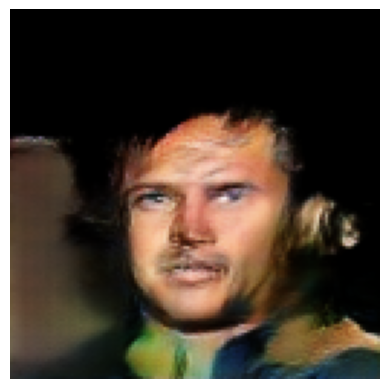

In [223]:
#male
noise = tf.random.normal([1, 100])
# noise += .5
female = noise-gen_vector
male = noise+gen_vector
with tf.device('/CPU:0'):
    generated_images = generator(male, training=False)

generated_images = (generated_images + 1) / 2.0

plt.imshow(generated_images[0])
plt.axis('off')

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

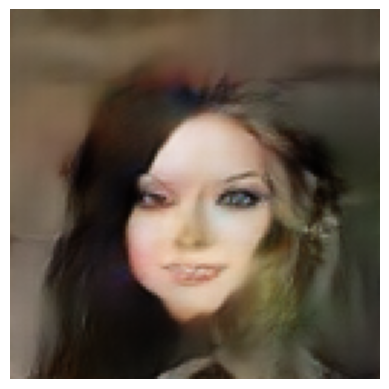

In [190]:
#female
noise = tf.random.normal([1, 100])
# noise += .5
female = noise-gen_vector
male = noise+gen_vector
with tf.device('/CPU:0'):
    generated_images = generator(female, training=False)

generated_images = (generated_images + 1) / 2.0

plt.imshow(generated_images[0])
plt.axis('off')

### Generate and Display a Grid of Male Faces

This cell defines and uses a function `generate_male_images_grid` to generate and display a grid of male faces.
- The function takes the generator `model`, `noise_dim`, and `num_images` as input.
- It creates a figure and a grid of subplots using `plt.subplots`.
- It iterates to generate `num_images` faces.
- For each image, it generates a random noise vector and adds the `gen_vector` to it to bias the generation towards male features.
- It generates the image using the `generator` with the manipulated noise.
- The generated image is rescaled and displayed in one of the subplots.
- Titles are added to each subplot.
- Finally, the grid of images is displayed.

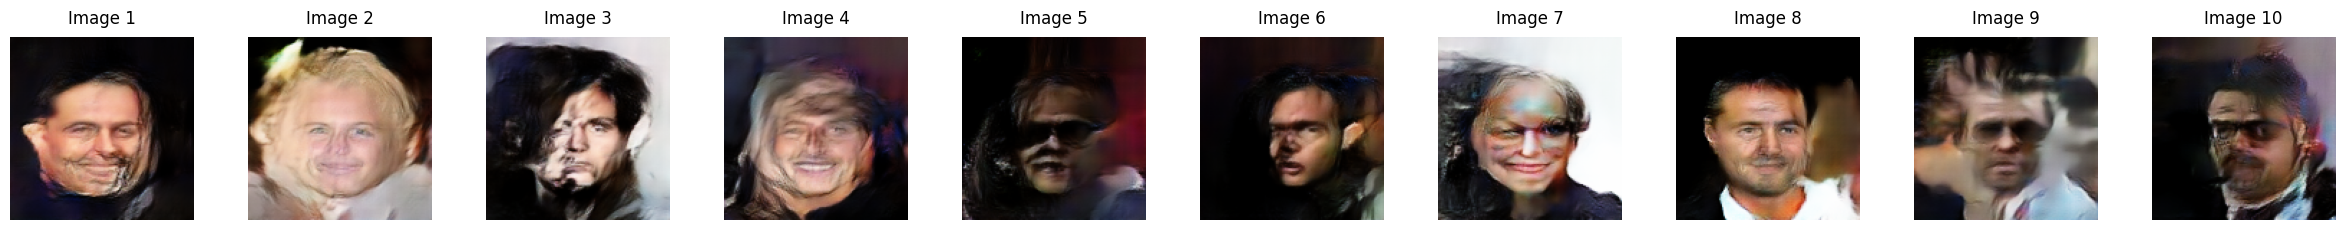

In [186]:
def generate_male_images_grid(model, noise_dim=100, num_images=10):

    fig, axes = plt.subplots(1, num_images, figsize=(30, 5))  # Wider figure

    for i in range(num_images):
        noise = tf.random.normal([1, noise_dim])
        # female = noise-gen_vector
        male = noise+gen_vector
        with tf.device('/CPU:0'):
            generated_image = model(male, training=False)
        generated_image = (generated_image + 1) / 2.0

        axes[i].imshow(generated_image[0])
        axes[i].axis('off')
        axes[i].set_title(f"Image {i+1}", fontsize=12, pad=10)

    plt.subplots_adjust(wspace=0.3)
    plt.show()

# Generate and display 10 images in a spaced 1x10 layout
generate_male_images_grid(generator)


### Generate and Display a Grid of Alternating Female Faces

This cell defines and uses a function `generate_female_images_grid` to generate and display a grid of faces with alternating genders.
- The function is similar to `generate_male_images_grid` but is modified to generate `num_images` (defaulting to 20) and arrange them in a 2x10 grid.
- Inside the loop, it checks the index `i`. If the index is even, it subtracts `gen_vector` to generate a female-biased face; if the index is odd, it adds `gen_vector` to generate a male-biased face.
- The generated images are displayed in the grid.

### Gender Classification (Requires Classifier Model)

This cell is intended for classifying the gender of a generated face using a pre-trained gender classifier model.
- **Note:** This cell requires the `gender_classifier.keras` model file. As noted in previous interactions, the path `/kaggle/input/gender-classifier-mobilenet/keras/gender-classifier-mobilenet/1/gender_classifier.keras` is specific to a Kaggle environment and needs to be updated to the correct path in your Colab environment for this cell to work.
- It loads the classifier model.
- It generates a single face (in this case, a male-biased face).
- The generated image is resized to the input size expected by the classifier (224x224).
- The classifier predicts the gender of the generated face.
- The predicted label ("Male" or "Female") and the prediction probability are displayed as the title of the image.
- The generated image is displayed.

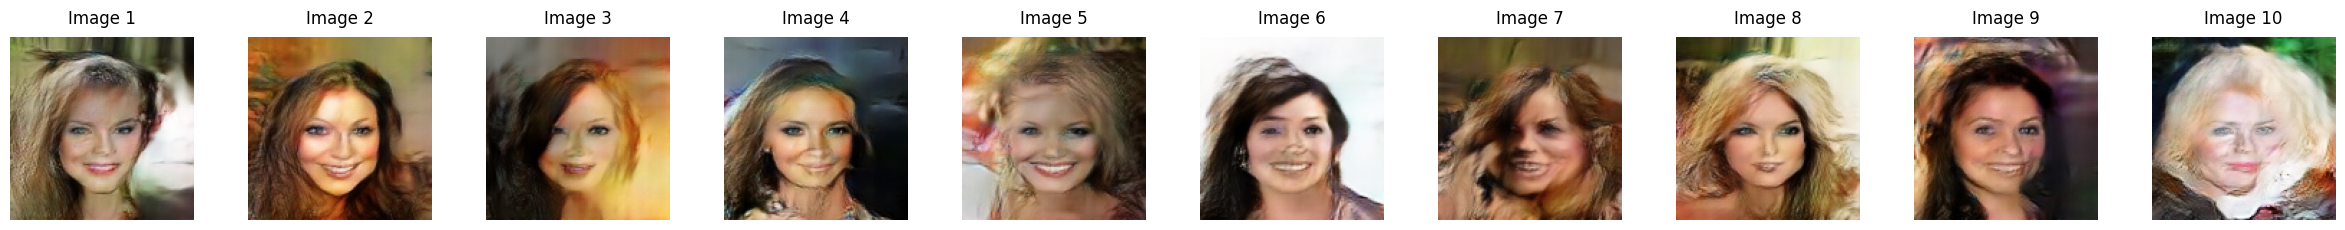

In [187]:
def generate_female_images_grid(model, noise_dim=100, num_images=10):

    fig, axes = plt.subplots(1, num_images, figsize=(30, 5))  # Wider figure

    for i in range(num_images):
        noise = tf.random.normal([1, noise_dim])
        female = noise-gen_vector
        # male = noise+gen_vector
        with tf.device('/CPU:0'):
            generated_image = model(female, training=False)
        generated_image = (generated_image + 1) / 2.0

        axes[i].imshow(generated_image[0])
        axes[i].axis('off')
        axes[i].set_title(f"Image {i+1}", fontsize=12, pad=10)

    plt.subplots_adjust(wspace=0.3)
    plt.show()

# Generate and display 10 images in a spaced 1x10 layout
generate_female_images_grid(generator)

#**Summary**

This project focuses on Face Generation and Gender Style Transfer using Generative Adversarial Networks (GANs).

The notebook demonstrates the following steps:

Cloning Repositories: It starts by cloning two GitHub repositories: one for a pre-trained Face Generator GAN and another containing a pre-trained Gender Style Transfer Vector.
Loading Models and Vectors: It loads the pre-trained GAN model (generator_700.h5) and the gender style vector (gender_vec.npy).
Face Generation: It shows how to generate synthetic faces using the loaded GAN model by providing random noise vectors as input.
Gender Style Transfer: It demonstrates how to manipulate the gender appearance of the generated faces by adding or subtracting the loaded gender style vector to the noise vector before feeding it to the generator. This allows for biasing the generated faces towards more male or female features.
Visualization: The notebook includes code to display the generated faces, both individual ones and grids of faces, to visualize the results of the generation and gender manipulation.
Gender Classification (Partial): There is an attempt to include gender classification of the generated faces using a separate classifier model, although this part requires the user to provide the correct path to the classifier model file.
In essence, the project explores the use of GANs for creating synthetic faces and how latent space manipulation with a pre-trained style vector can be used to control specific attributes like gender in the generated images.